### Install pre-requistes


In [1]:
!pip install --upgrade pip SPARQLWrapper pandas matplotlib ftfy --quiet 
import sys
!{sys.executable} -m pip uninstall -y py4cytoscape
!{sys.executable} -m pip install py4cytoscape

Found existing installation: py4cytoscape 1.13.0
Uninstalling py4cytoscape-1.13.0:
  Successfully uninstalled py4cytoscape-1.13.0
  Using cached py4cytoscape-1.13.0-py3-none-any.whl.metadata (5.1 kB)
Using cached py4cytoscape-1.13.0-py3-none-any.whl (196 kB)



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ENDPOINT_URL = "http://localhost:7200/repositories/KG-Questionnaire_NoPlatform"

PREFIXES = """\
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ds:   <http://digistrucmed.org/questionnaire#>
"""

In [3]:
def run_query(query: str) -> pd.DataFrame:
    """Run a SPARQL SELECT query and return the results as a Pandas DataFrame."""
    sparql = SPARQLWrapper(ENDPOINT_URL)
    sparql.setReturnFormat(JSON)
    sparql.setQuery(PREFIXES + "\n" + query)
    results = sparql.query().convert()

    cols = results["head"].get("vars", [])
    rows = []
    for b in results["results"]["bindings"]:
        row = {}
        for c in cols:
            val = b.get(c, {}).get("value")
            row[c] = val
        rows.append(row)
    return pd.DataFrame(rows, columns=cols)

def short_uri(uri):
    """Return the local name of a URI (the part after the last '#' or '/')."""
    if uri is None or (isinstance(uri, float) and pd.isna(uri)):
        return uri
    uri = str(uri)
    return uri.rsplit("#", 1)[-1] if "#" in uri else uri.rsplit("/", 1)[-1]

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)


## 1. Schema Overview
What is the graph

In [4]:
q1 = """\
SELECT ?type (COUNT(?s) AS ?count)
WHERE { ?s a ?type . }
GROUP BY ?type
ORDER BY DESC(?count)
"""
df1 = run_query(q1)
df1["count"] = pd.to_numeric(df1["count"], errors="coerce")
df1[["type", "count"]]


,type,count
0,http://digistrucmed.org/questionnaire#Answered,3154
1,http://digistrucmed.org/questionnaire#User,273
2,http://digistrucmed.org/questionnaire#Answer,266
3,http://digistrucmed.org/questionnaire#Nominal,151
4,http://digistrucmed.org/questionnaire#Ordinal,115
5,http://digistrucmed.org/questionnaire#Question,42
6,http://www.w3.org/1999/02/22-rdf-syntax-ns#Property,38
7,http://www.w3.org/2002/07/owl#TransitiveProperty,4
8,http://www.w3.org/2002/07/owl#SymmetricProperty,4
9,http://www.w3.org/2000/01/rdf-schema#Class,3


## 2. Predicate Usage

How nodes are connected.


In [5]:
q2 = """\
SELECT ?predicate (COUNT(*) AS ?count)
WHERE { ?s ?predicate ?o .
FILTER(STRSTARTS(STR(?predicate), STR(ds:)))}
GROUP BY ?predicate
ORDER BY DESC(?count)
"""

df2 = run_query(q2)
df2["count"] = pd.to_numeric(df2["count"], errors="coerce")
df2["percentage"] = (df2["count"] / df2["count"].sum() * 100).round(2)
df2[["predicate", "count", "percentage"]]


,predicate,count,percentage
0,http://digistrucmed.org/questionnaire#VisitId,3154,10.34
1,http://digistrucmed.org/questionnaire#hasAnswer,3154,10.34
2,http://digistrucmed.org/questionnaire#startTime,3154,10.34
3,http://digistrucmed.org/questionnaire#endTime,3154,10.34
4,http://digistrucmed.org/questionnaire#speed,3154,10.34
5,http://digistrucmed.org/questionnaire#rawResponseValue,3154,10.34
6,http://digistrucmed.org/questionnaire#answeredByUser,3154,10.34
7,http://digistrucmed.org/questionnaire#answeredInQuestionnaire,3154,10.34
8,http://digistrucmed.org/questionnaire#hasQuestion,3154,10.34
9,http://digistrucmed.org/questionnaire#hasAnswerCategory,304,1.00


C:\Users\tehranim.TIB.001\AppData\Local\Temp\ipykernel_19752\1156781165.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


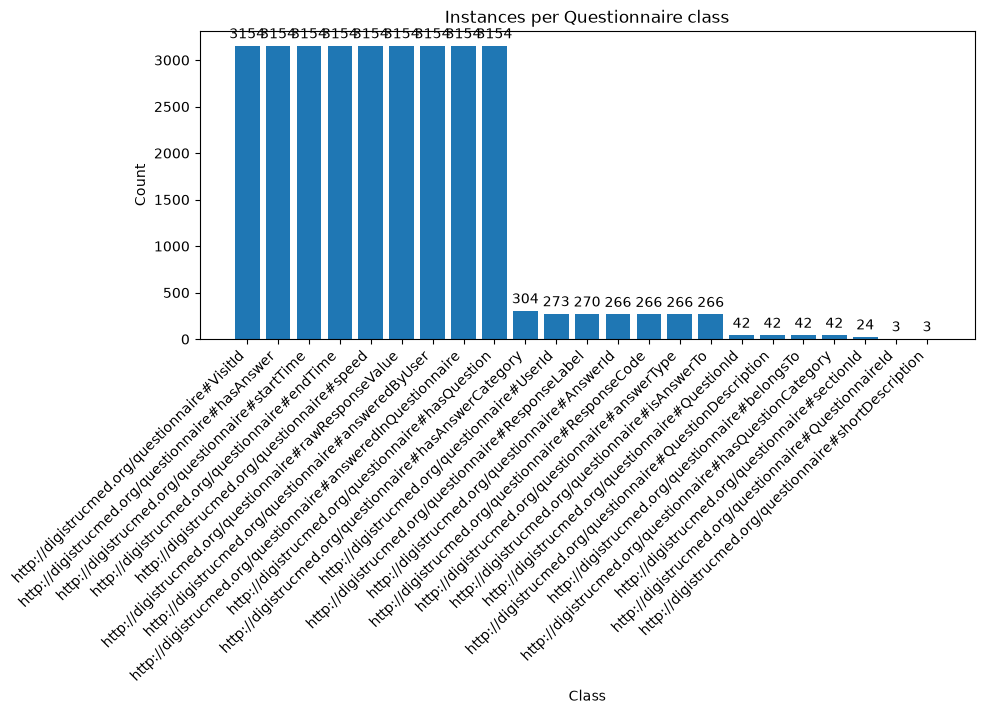

In [6]:
if not df2.empty:
    df2_plot = df2.dropna(subset=["count"]).sort_values("count", ascending=False)
    plt.figure(figsize=(10, 4))
    plt.xticks(rotation=45, ha="right")
    plt.title("Instances per Questionnaire class")
    plt.ylabel("Count")
    plt.xlabel("Class")
    bars = plt.bar(df2_plot["predicate"], df2_plot["count"])
    plt.bar_label(bars, padding=3)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for query 2.")


## 3. Walk from a Question to its answers

Explore the number of each answer to each question.


In [7]:
q3 = """\
SELECT ?questionDesc ?category (COUNT(DISTINCT ?resp) AS ?numPeople)
WHERE {
  ?question a ds:Question ; ds:QuestionDescription ?questionDesc .
  ?resp a ds:Answered ; ds:hasAnswer ?answer .
  ?answer ds:isAnswerTo ?question ; ds:hasAnswerCategory ?category .
}
GROUP BY ?questionDesc ?category
ORDER BY DESC (?numPeople)
"""
df3 = run_query(q3)
df3["numPeople"] = pd.to_numeric(df3["numPeople"], errors="coerce")

# Keep the raw query result visible first.
display(df3.head(20))

# Compact KG-oriented summary: how many category entries and respondents each question has.
summary3 = (
    df3.groupby("questionDesc", as_index=False)
    .agg(
        categories=("category", "nunique"),
        total_respondents=("numPeople", "sum"),
        avg_respondents=("numPeople", "mean"),
        max_category_count=("numPeople", "max"),
    )
    .sort_values("total_respondents", ascending=False)
    .round(2)
    .reset_index(drop=True)
)

display(summary3.head(20))



,questionDesc,category,numPeople
0,Medienart,http://digistrucmed.org/questionnaire#Format,162
1,Fragenbeantwortung: Wurden all Ihre Fragen zum Thema ausreichend beantwortet?,http://digistrucmed.org/questionnaire#very_positive,97
2,Verst�ndnis: Wie gut haben Sie den Stoff der einzelnen Lektionen verstanden?,http://digistrucmed.org/questionnaire#very_positive,97
3,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,http://digistrucmed.org/questionnaire#very_positive,90
4,Gesamterfahrung: Wie w�rden Sie die Gesamterfahrung mit den zur Verf�gung gestellten Inhalten in diesem Modul bewerten?,http://digistrucmed.org/questionnaire#very_positive,89
5,neue Erkenntnisse: Haben Sie neue Erkenntnisse und Informationen durch die Bearbeitung des Moduls erhalten?,http://digistrucmed.org/questionnaire#very_positive,75
6,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,http://digistrucmed.org/questionnaire#positive,58
7,Gesamterfahrung: Wie w�rden Sie die Gesamterfahrung mit den zur Verf�gung gestellten Inhalten in diesem Modul bewerten?,http://digistrucmed.org/questionnaire#positive,58
8,Verst�ndnis: Wie gut haben Sie den Stoff der einzelnen Lektionen verstanden?,http://digistrucmed.org/questionnaire#positive,48
9,neue Erkenntnisse: Haben Sie neue Erkenntnisse und Informationen durch die Bearbeitung des Moduls erhalten?,http://digistrucmed.org/questionnaire#positive,44


,questionDesc,categories,total_respondents,avg_respondents,max_category_count
0,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,5,162,32.40,90
1,Verst�ndnis: Wie gut haben Sie den Stoff der einzelnen Lektionen verstanden?,5,162,32.40,97
2,Fragenbeantwortung: Wurden all Ihre Fragen zum Thema ausreichend beantwortet?,5,162,32.40,97
3,Gesamterfahrung: Wie w�rden Sie die Gesamterfahrung mit den zur Verf�gung gestellten Inhalten in diesem Modul bewerten?,5,162,32.40,89
4,Medienart,1,162,162.00,162
5,neue Erkenntnisse: Haben Sie neue Erkenntnisse und Informationen durch die Bearbeitung des Moduls erhalten?,5,162,32.40,75
6,A1,4,45,11.25,20
7,A2,4,45,11.25,18
8,"System Usability Scale (SUS): Ich denke, es gibt zu viele Inkonsistenzen auf der Lernplattform. (umgepolt)",5,45,9.00,17
9,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne h�ufiger benutzen.",5,45,9.00,20


,question,num_categories,total_distinct_respondents,avg_respondents_per_category,largest_category_count
0,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,5,162,32.40,90
1,Verständnis: Wie gut haben Sie den Stoff der einzelnen Lektionen verstanden?,5,162,32.40,97
2,Fragenbeantwortung: Wurden all Ihre Fragen zum Thema ausreichend beantwortet?,5,162,32.40,97
3,Gesamterfahrung: Wie würden Sie die Gesamterfahrung mit den zur Verfügung gestellten Inhalten in diesem Modul bewerten?,5,162,32.40,89
4,Medienart,1,162,162.00,162
5,neue Erkenntnisse: Haben Sie neue Erkenntnisse und Informationen durch die Bearbeitung des Moduls erhalten?,5,162,32.40,75
6,A1,4,45,11.25,20
7,A2,4,45,11.25,18
8,"System Usability Scale (SUS): Ich denke, es gibt zu viele Inkonsistenzen auf der Lernplattform. (umgepolt)",5,45,9.00,17
9,"System Usability Scale (SUS): Ich denke, ich w�rde die Lernplattform gerne häufiger benutzen.",5,45,9.00,20


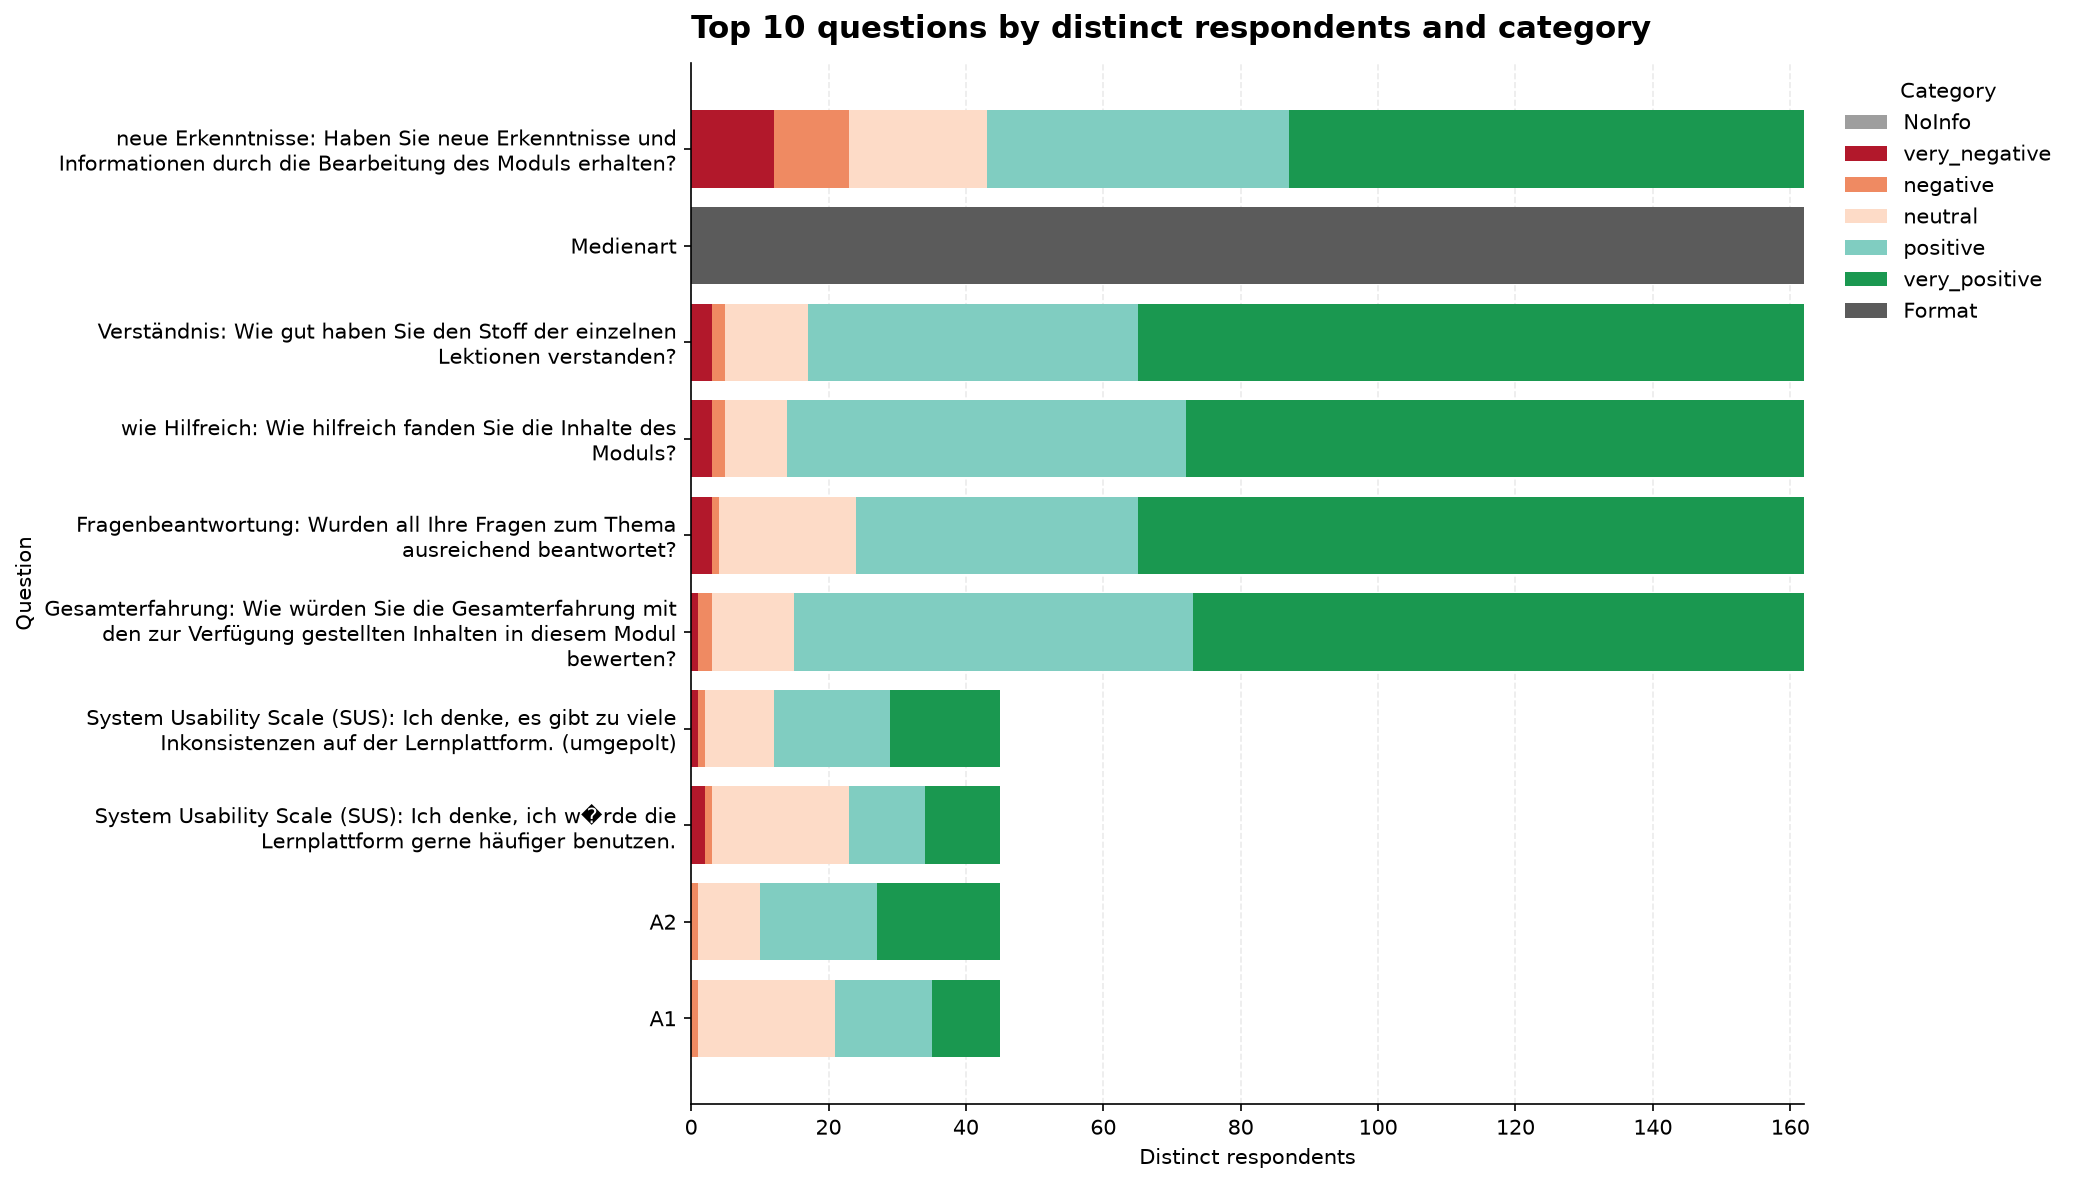

category,http://digistrucmed.org/questionnaire#NoInfo,http://digistrucmed.org/questionnaire#very_negative,http://digistrucmed.org/questionnaire#negative,http://digistrucmed.org/questionnaire#neutral,http://digistrucmed.org/questionnaire#positive,http://digistrucmed.org/questionnaire#very_positive,http://digistrucmed.org/questionnaire#Format
questionDesc,,,,,,,
A1,0,0,1,20,14,10,0
A2,0,0,1,9,17,18,0
"System Usability Scale (SUS): Ich denke, ich w�rde die\nLernplattform gerne häufiger benutzen.",0,2,1,20,11,11,0
"System Usability Scale (SUS): Ich denke, es gibt zu viele\nInkonsistenzen auf der Lernplattform. (umgepolt)",0,1,1,10,17,16,0
Gesamterfahrung: Wie würden Sie die Gesamterfahrung mit\nden zur Verfügung gestellten Inhalten in diesem Modul\nbewerten?,0,1,2,12,58,89,0
Fragenbeantwortung: Wurden all Ihre Fragen zum Thema\nausreichend beantwortet?,0,3,1,20,41,97,0
wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des\nModuls?,0,3,2,9,58,90,0
Verständnis: Wie gut haben Sie den Stoff der einzelnen\nLektionen verstanden?,0,3,2,12,48,97,0
Medienart,0,0,0,0,0,0,162


,category,questions,total_distinct_respondents,avg_distinct_respondents
0,http://digistrucmed.org/questionnaire#very_positive,39,957,24.54
1,http://digistrucmed.org/questionnaire#positive,39,793,20.33
2,http://digistrucmed.org/questionnaire#neutral,39,401,10.28
3,http://digistrucmed.org/questionnaire#Format,1,162,162.00
4,http://digistrucmed.org/questionnaire#negative,30,83,2.77
5,http://digistrucmed.org/questionnaire#very_negative,20,54,2.70
6,http://digistrucmed.org/questionnaire#NoInfo,1,1,1.00


In [ ]:
import html
import re
import textwrap

def clean_label(value):
    """Normalize question text for display in tables and plots."""
    if pd.isna(value):
        return value

    text = html.unescape(str(value)).strip()
    text = " ".join(text.split())

    # First try to repair mojibake with a deterministic decode path.
    candidates = [text]
    for encoding in ("latin1", "cp1252"):
        try:
            candidates.append(text.encode(encoding).decode("utf-8"))
        except UnicodeError:
            pass

    try:
        from ftfy import fix_text
        candidates.append(fix_text(text))
    except ImportError:
        pass

    # Apply a small fallback dictionary for labels that were already replaced
    # with the Unicode replacement character in the source export.
    replacements = {
        "Verst�ndnis": "Verständnis",
        "w�rden": "würden",
        "Verf�gung": "Verfügung",
        "h�ufiger": "häufiger",
        "f�hlte": "fühlte",
        "k�dnte": "könnte",
        "n�tigen": "nötigen",
        "n�tig": "nötig",
        "umst�ndlich": "umständlich",
        "unterst�tzung": "unterstützung",
    }

    def apply_replacements(candidate):
        for broken, fixed in replacements.items():
            candidate = candidate.replace(broken, fixed)
        return candidate

    candidates = [apply_replacements(candidate) for candidate in candidates]
    candidates = [candidate for candidate in candidates if candidate]

    def score(candidate):
        penalty = candidate.count("�") * 10
        penalty += len(re.findall(r"[ÃÂ]", candidate)) * 5
        penalty += sum(candidate.count(token) for token in ("Verst�ndnis", "w�rden", "Verf�gung", "h�ufiger", "f�hlte", "k�dnte", "umst�ndlich")) * 20
        return penalty

    text = min(candidates, key=score) if candidates else text
    return text

summary3["question_label"] = summary3["questionDesc"].map(clean_label)
summary3["top_category_count"] = summary3["max_category_count"]

display(
    summary3[["question_label", "categories", "total_respondents", "avg_respondents", "top_category_count"]]
    .head(20)
    .rename(columns={
        "question_label": "question",
        "categories": "num_categories",
        "total_respondents": "total_distinct_respondents",
        "avg_respondents": "avg_respondents_per_category",
        "top_category_count": "largest_category_count",
    })
)

# Use the top 10 questions, but show the full category distribution for each one.
top_questions = summary3.head(10).sort_values("total_respondents", ascending=True).copy()
top_questions["plot_label"] = top_questions["question_label"].map(lambda value: textwrap.fill(value, width=58))

category_order = [
    "http://digistrucmed.org/questionnaire#NoInfo",
    "http://digistrucmed.org/questionnaire#very_negative",
    "http://digistrucmed.org/questionnaire#negative",
    "http://digistrucmed.org/questionnaire#neutral",
    "http://digistrucmed.org/questionnaire#positive",
    "http://digistrucmed.org/questionnaire#very_positive",
    "http://digistrucmed.org/questionnaire#Format",
]
available_categories = [category for category in category_order if category in df3["category"].unique()]

top_question_matrix = (
    df3[df3["questionDesc"].isin(top_questions["questionDesc"])]
    .pivot_table(
        index="questionDesc",
        columns="category",
        values="numPeople",
        fill_value=0,
        aggfunc="sum",
    )
    .reindex(index=top_questions["questionDesc"], columns=available_categories, fill_value=0)
    .rename(index=dict(zip(top_questions["questionDesc"], top_questions["plot_label"])))
)

fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
left = pd.Series(0, index=top_question_matrix.index)

palette = {
    "http://digistrucmed.org/questionnaire#NoInfo": "#9e9e9e",
    "http://digistrucmed.org/questionnaire#very_negative": "#b2182b",
    "http://digistrucmed.org/questionnaire#negative": "#ef8a62",
    "http://digistrucmed.org/questionnaire#neutral": "#fddbc7",
    "http://digistrucmed.org/questionnaire#positive": "#80cdc1",
    "http://digistrucmed.org/questionnaire#very_positive": "#1a9850",
    "http://digistrucmed.org/questionnaire#Format": "#5b5b5b",
}

for category in available_categories:
    values = top_question_matrix[category]
    ax.barh(
        top_question_matrix.index,
        values,
        left=left,
        label=short_uri(category),
        color=palette.get(category, "#2b7bbb"),
        edgecolor="none",
)
    left = left + values

ax.set_title("Top 10 questions by distinct respondents and category", loc="left", pad=12, fontsize=15, fontweight="bold")
ax.set_xlabel("Distinct respondents")
ax.set_ylabel("Question")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.margins(x=0.05)

plt.tight_layout()
plt.show()

# Heatmap-style table: useful to inspect question/category coverage in the KG.
display(top_question_matrix)

# Compact category totals across the entire KG.
category_summary = (
    df3.groupby("category", as_index=False)
    .agg(
        questions=("questionDesc", "nunique"),
        total_distinct_respondents=("numPeople", "sum"),
        avg_distinct_respondents=("numPeople", "mean"),
    )
    .sort_values("total_distinct_respondents", ascending=False)
    .round(2)
    .reset_index(drop=True)
)

display(category_summary)

## 4. Trace one participant's full path through the graph
Trace the answers submitted by the participant with UserId=100.

In [17]:
q4 = """
SELECT ?questionDesc ?rawResponseValue ?category ?questionnaire
WHERE {
  VALUES ?user { ds:100 }   # swap in any UserId
  ?resp a ds:Answered ; ds:answeredByUser ?user ;
        ds:rawResponseValue ?rawResponseValue ;
        ds:answeredInQuestionnaire ?questionnaire ;
        ds:hasAnswer ?answer .
    ?answer ds:isAnswerTo ?question ; ds:hasAnswerCategory ?category .
  ?question ds:QuestionDescription ?questionDesc .
}
ORDER BY ?questionnaire ?questionDesc
"""
df4 = run_query(q4)
df4["questionDesc"] = df4["questionDesc"].map(clean_label)
df4[["questionDesc", "rawResponseValue", "category", "questionnaire"]]

,questionDesc,rawResponseValue,category,questionnaire
0,A1,5,http://digistrucmed.org/questionnaire#very_positive,http://digistrucmed.org/questionnaire#uMARS
1,A2,5,http://digistrucmed.org/questionnaire#very_positive,http://digistrucmed.org/questionnaire#uMARS
2,A3,4,http://digistrucmed.org/questionnaire#positive,http://digistrucmed.org/questionnaire#uMARS
3,A4,5,http://digistrucmed.org/questionnaire#very_positive,http://digistrucmed.org/questionnaire#uMARS
4,B1,5,http://digistrucmed.org/questionnaire#very_positive,http://digistrucmed.org/questionnaire#uMARS
5,B2,4,http://digistrucmed.org/questionnaire#positive,http://digistrucmed.org/questionnaire#uMARS
6,B3,5,http://digistrucmed.org/questionnaire#very_positive,http://digistrucmed.org/questionnaire#uMARS
7,C1,4,http://digistrucmed.org/questionnaire#positive,http://digistrucmed.org/questionnaire#uMARS
8,C2,4,http://digistrucmed.org/questionnaire#positive,http://digistrucmed.org/questionnaire#uMARS
9,C3,4,http://digistrucmed.org/questionnaire#positive,http://digistrucmed.org/questionnaire#uMARS


## 4.Find gaps (orphan/disconnected nodes)

In [19]:
q4 = """
SELECT ?question ?questionDesc
WHERE {
  ?question a ds:Question ; ds:QuestionDescription ?questionDesc .
  FILTER NOT EXISTS { ?resp a ds:Answered ; ds:hasAnswer/ds:isAnswerTo ?question . }
}
"""
df4 = run_query(q4)
df4["questionDesc"] = df4["questionDesc"].map(clean_label)
df4[["question", "questionDesc"]]

,question,questionDesc
0,http://digistrucmed.org/questionnaire#M007_01,Freitext positiv: Hier k�nnen Sie Ihre Antwort verfassen
1,http://digistrucmed.org/questionnaire#M008_01,Freitext W�nsche: Hier k�nnen Sie Ihre Antwort verfassen


## 4.Network Degree Centrality of Questionnaire Entities
Using predicate edges.

Number of nodes: 3797
Number of edges: 13851


,label,type,centrality,node
42,ME1,"ModuleEvaluation, Questionnaire",0.351949,http://digistrucmed.org/questionnaire#ME1
44,uMARS,"Questionnaire, uMARS",0.347734,http://digistrucmed.org/questionnaire#uMARS
43,SUS,"Questionnaire, SUS",0.142255,http://digistrucmed.org/questionnaire#SUS
0,M002_01,Question,0.047682,http://digistrucmed.org/questionnaire#M002_01
4,M006_01,Question,0.047682,http://digistrucmed.org/questionnaire#M006_01
2,M004_01,Question,0.047682,http://digistrucmed.org/questionnaire#M004_01
1,M003_01,Question,0.047682,http://digistrucmed.org/questionnaire#M003_01
7,M010_01,Question,0.047682,http://digistrucmed.org/questionnaire#M010_01
3,M005,Question,0.045838,http://digistrucmed.org/questionnaire#M005
5,M007_01,Question,0.044784,http://digistrucmed.org/questionnaire#M007_01


Average number of neighbors (overall): 7.295759810376613


,type_label,nodes,avg_neighbors,max_neighbors
2,ModuleEvaluation,1,1336.000000,1336
9,uMARS,1,1320.000000,1320
6,Questionnaire,3,1065.333333,1336
7,SUS,1,540.000000,540
5,Question,42,85.428571,181
4,Ordinal,115,15.086957,70
8,User,273,13.553114,26
0,Answer,266,13.357143,92
3,Nominal,151,12.039735,92
1,Answered,3154,4.000000,4


Average shortest path length (largest component): 3.9101461888413374


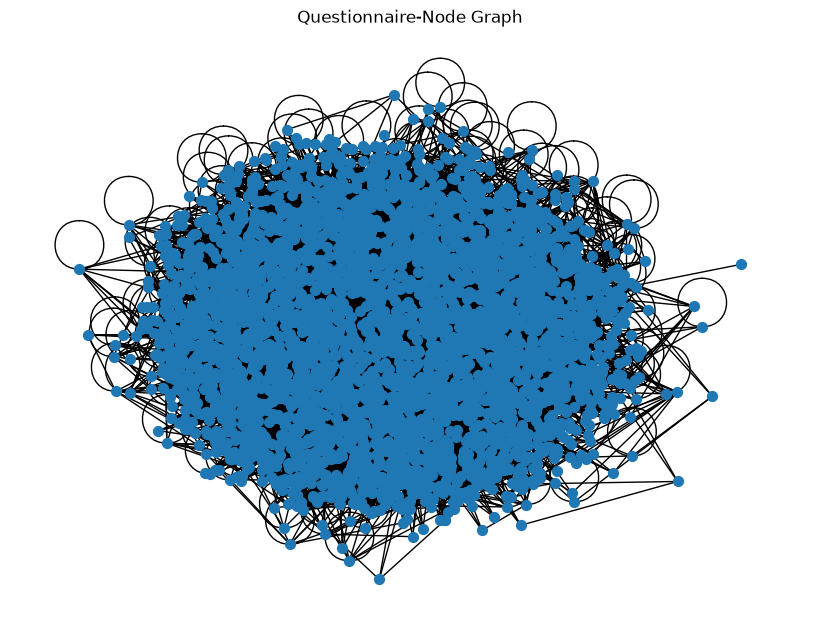

In [9]:
# Build a Questionnaire relations graph
q_edges = """
SELECT DISTINCT ?s ?p ?o
WHERE {
  ?s ?p ?o .
  FILTER(isIRI(?s) && isIRI(?o))
  FILTER(STRSTARTS(STR(?p), "http://digistrucmed.org/questionnaire#"))
}
"""

q_node_types = """
SELECT DISTINCT ?node ?type
WHERE {
  ?node rdf:type ?type .
  FILTER(STRSTARTS(STR(?type), "http://digistrucmed.org/questionnaire#"))
}
"""

# Run queries
df_edges = run_query(q_edges)
df_node_types = run_query(q_node_types)

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

def short_uri(x):
    x = str(x)
    return x.rsplit("#", 1)[-1] if "#" in x else x.rsplit("/", 1)[-1]

G = nx.Graph()
for _, r in df_edges.iterrows():
    G.add_edge(r["s"], r["o"], predicate=short_uri(r["p"]))

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Degree centrality
deg_centrality = nx.degree_centrality(G)

type_labels = df_node_types.copy()
type_labels["type_label"] = type_labels["type"].map(short_uri)

node_type_map = (
    type_labels.groupby("node")["type_label"]
    .apply(lambda values: ", ".join(sorted(set(values))))
    .to_dict()
)

df_deg = (
    pd.DataFrame(deg_centrality.items(), columns=["node", "centrality"])
      .assign(
          label=lambda d: d["node"].map(short_uri),
          type=lambda d: d["node"].map(node_type_map).fillna("Unknown")
      )
      .sort_values("centrality", ascending=False)
)

display(df_deg[["label", "type", "centrality", "node"]].head(20))

# Average number of neighbors
degrees = dict(G.degree())
avg_neighbors = sum(degrees.values()) / len(degrees) if degrees else 0
print("Average number of neighbors (overall):", avg_neighbors)

# Average neighbors by real questionnaire class
degree_df = pd.DataFrame(degrees.items(), columns=["node", "degree"])

typed_degree_df = type_labels.merge(degree_df, on="node", how="inner")

avg_neighbors_by_type = (
    typed_degree_df.groupby("type_label", as_index=False)
    .agg(
        nodes=("node", "nunique"),
        avg_neighbors=("degree", "mean"),
        max_neighbors=("degree", "max")
    )
    .sort_values("avg_neighbors", ascending=False)
)

display(avg_neighbors_by_type)

# Additional global metrics
if G.number_of_nodes() > 0:
    try:
        if nx.is_connected(G):
            asp = nx.average_shortest_path_length(G)
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            H = G.subgraph(largest_cc).copy()
            asp = nx.average_shortest_path_length(H)

        print("Average shortest path length (largest component):", asp)
    except Exception as e:
        print("Could not compute average shortest path length:", e)

# Network Visualization
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)

nx.draw(G, pos, with_labels=False, node_size=50)
plt.title("Questionnaire-Node Graph")
plt.show()

## 5. Centrality analysis in Cytoscape (py4cytoscape)

This sends the questionnaire relation graph to a running Cytoscape desktop session, runs Cytoscape's NetworkAnalyzer, and retrieves the node centrality measures. Start Cytoscape before running this cell.

In [10]:
import py4cytoscape as p4c

# Cytoscape must be open locally (Apps -> CyREST is included by default).
try:
    p4c.cytoscape_ping()
except Exception as exc:
    raise ConnectionError(
        'Cytoscape is not reachable. Open Cytoscape, wait for it to finish starting, then rerun this cell.'
    ) from exc

# Reuse df_edges created in Section 4. Cytoscape expects id/source/target columns.
nodes_cy = pd.DataFrame({'id': sorted(G.nodes())})
nodes_cy['label'] = nodes_cy['id'].map(lambda uri: str(uri).rsplit('#', 1)[-1])
edges_cy = df_edges[['s', 'o', 'p']].rename(
    columns={'s': 'source', 'o': 'target', 'p': 'predicate'}
)
edges_cy['interaction'] = edges_cy['predicate'].map(
    lambda uri: str(uri).rsplit('#', 1)[-1]
)

network_suid = p4c.create_network_from_data_frames(
    nodes=nodes_cy, edges=edges_cy,
    title='Questionnaire relation graph - centrality',
    collection='Questionnaire analysis'
)

# The graph was built as undirected in NetworkX, so analyse it as undirected here too.
p4c.set_current_network(network_suid)
p4c.analyze_network(directed=False)

# Retrieve the centrality results written by Cytoscape NetworkAnalyzer.
node_table = p4c.get_table_columns(table='node', network=network_suid)
centrality_metrics = [
    metric for metric in [
        'Degree', 'BetweennessCentrality', 'ClosenessCentrality',
        'Radiality', 'Stress', 'ClusteringCoefficient'
    ] if metric in node_table.columns
]

centrality_df = (
    node_table[['name'] + centrality_metrics]
    .rename(columns={'name': 'node'})
    .sort_values(
        by='BetweennessCentrality' if 'BetweennessCentrality' in centrality_metrics else 'Degree',
        ascending=False
    )
    .reset_index(drop=True)
)

display(centrality_df.head(20))
centrality_df.to_csv('questionnaire_cytoscape_centrality.csv', index=False)
print(f'Created Cytoscape network {network_suid} and saved centrality results for {len(centrality_df)} nodes.')

You are connected to Cytoscape!
Applying default style...
Applying preferred layout


,node,Degree,BetweennessCentrality,ClosenessCentrality,Radiality,Stress,ClusteringCoefficient
0,http://digistrucmed.org/questionnaire#ME1,1336,0.321837,0.316994,0.998387,1205271972,0.001489
1,http://digistrucmed.org/questionnaire#uMARS,1320,0.257089,0.330173,0.998482,48496920,0.001489
2,http://digistrucmed.org/questionnaire#M006_01,181,0.144311,0.344215,0.998574,36683580,0.020589
3,http://digistrucmed.org/questionnaire#very_positive,44,0.141516,0.346825,0.998590,726875340,0.000000
4,http://digistrucmed.org/questionnaire#Quality,16,0.129742,0.320852,0.998416,24641194,0.000000
5,http://digistrucmed.org/questionnaire#positive,44,0.110969,0.341152,0.998554,337090818,0.000000
6,http://digistrucmed.org/questionnaire#Agreement,16,0.083936,0.258477,0.997853,14038668,0.000000
7,http://digistrucmed.org/questionnaire#neutral,44,0.061083,0.327722,0.998465,89244852,0.000000
8,http://digistrucmed.org/questionnaire#UM18,64,0.043670,0.328345,0.998469,7550444,0.050767
9,http://digistrucmed.org/questionnaire#Degree,5,0.041859,0.310334,0.998337,7350546,0.000000


Created Cytoscape network 92228 and saved centrality results for 3797 nodes.


,question_short,questionText,responseCode,answer,frequency,percentage
0,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,10,sehr [10],61,36.75
1,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,8,Skalenwert 8,44,26.51
2,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,9,Skalenwert 9,29,17.47
3,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,7,Skalenwert 7,14,8.43
4,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,5,Skalenwert 5,5,3.01
...,...,...,...,...,...,...
95,SU01_08,System Usability Scale (SUS): Ich fand die Lernplattform sehr umst�ndlich zu nutzen. (umgepolt),5,trifft gar nicht zu,24,45.28
96,SU01_08,System Usability Scale (SUS): Ich fand die Lernplattform sehr umst�ndlich zu nutzen. (umgepolt),4,Likert response 4,13,24.53
97,SU01_08,System Usability Scale (SUS): Ich fand die Lernplattform sehr umst�ndlich zu nutzen. (umgepolt),NaN,NaN,8,15.09
98,SU01_08,System Usability Scale (SUS): Ich fand die Lernplattform sehr umst�ndlich zu nutzen. (umgepolt),3,Likert response 3,6,11.32


,responseCode,answer,frequency,percentage
34,10,sehr gut [10],55,33.13
35,8,Skalenwert 8,46,27.71
36,9,Skalenwert 9,34,20.48
37,7,Skalenwert 7,12,7.23
38,6,Skalenwert 6,8,4.82
39,5,Skalenwert 5,4,2.41
40,NaN,NaN,4,2.41
41,1,sehr schlecht [1],1,0.60
42,3,Skalenwert 3,1,0.60
43,4,Skalenwert 4,1,0.60


TypeError: 'value' must be an instance of str or bytes, not a float

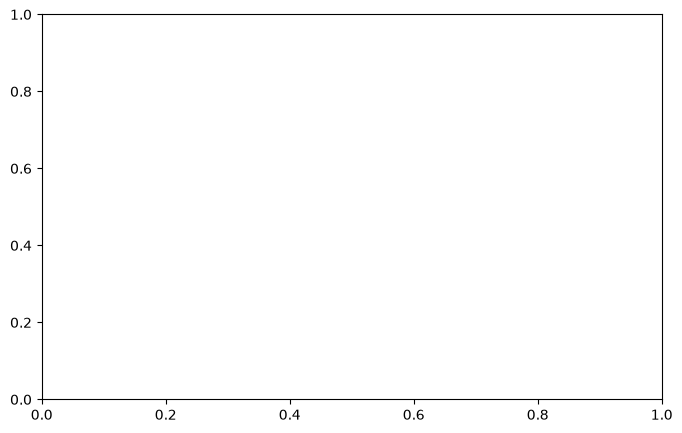

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Helper
def short_uri(x):
    if pd.isna(x):
        return x
    x = str(x)
    return x.split("#")[-1] if "#" in x else x

# ------------------------------------------------------------
# Simple answer statistics per question
# ------------------------------------------------------------

q_answer_stats = """
SELECT
    ?question
    ?questionText
    ?responseCode
    ?responseLabel
    (COUNT(DISTINCT ?answered) AS ?frequency)
WHERE {
    ?answered ds:hasQuestion ?question ;
              ds:hasAnswer ?answer .

    OPTIONAL { ?question ds:QuestionDescription ?questionText . }
    OPTIONAL { ?answer ds:ResponseCode ?responseCode . }
    OPTIONAL { ?answer ds:ResponseLabel ?responseLabel . }
}
GROUP BY ?question ?questionText ?responseCode ?responseLabel
ORDER BY ?question DESC(?frequency)
"""

df = run_query(q_answer_stats)

df["frequency"] = df["frequency"].astype(int)
df["question_short"] = df["question"].apply(short_uri)

df["answer"] = df["responseLabel"].fillna(df["responseCode"])
df["total_per_question"] = df.groupby("question")["frequency"].transform("sum")

df["percentage"] = (
    df["frequency"] / df["total_per_question"] * 100
).round(2)

df = df.sort_values(
    ["question_short", "frequency"],
    ascending=[True, False]
)

display(df[[
    "question_short",
    "questionText",
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]].head(100))

# For one specific question, show the distribution of answers
question_id = "M006_01"   # change this

one_question = df[df["question_short"] == question_id]

display(one_question[[
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]])

plt.figure(figsize=(8, 5))
plt.barh(one_question["answer"], one_question["frequency"])
plt.gca().invert_yaxis()
plt.xlabel("Number of answers")
plt.ylabel("Answer")
plt.title(f"Answer Statistics for {question_id}")
plt.tight_layout()
plt.show()

#For an overall view, show the most common answers across all questions
overall = (
    df.groupby(["responseCode", "answer"], dropna=False)["frequency"]
    .sum()
    .reset_index()
    .sort_values("frequency", ascending=False)
)

overall["percentage"] = (
    overall["frequency"] / overall["frequency"].sum() * 100
).round(2)

display(overall.head(30))